# CRM Layer — Exploratory Data Analysis

## What this layer represents

Otacon's CRM tracks the relationship management layer: accounts with health scores and tiers, sales activities (calls, emails, meetings, demos, QBRs), and the opportunity pipeline. This is where the business understands account health and forecasts future revenue.

**Tables:** `accounts` (2,000), `activities` (7,500), `opportunities` (2,000)

**Key questions:**
1. How healthy is the account base? What % is at risk?
2. Are sales reps active enough? Who's performing?
3. What does the pipeline look like? Can we forecast?
4. Are there enough QBRs happening? Are demos converting?
5. What's the relationship between health score and activity volume?

## 1. Setup

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
warnings.filterwarnings("ignore")

if os.path.exists("otacon.db"):
    DB_PATH = "otacon.db"
elif os.path.exists("../otacon.db"):
    DB_PATH = "../otacon.db"
else:
    raise FileNotFoundError("otacon.db not found. Run from project root or notebooks/ folder.")

conn = sqlite3.connect(DB_PATH)

def q(sql):
    return pd.read_sql_query(sql, conn)

def raw_vs_clean(raw_table, clean_view):
    raw = q(f"SELECT COUNT(*) as n FROM {raw_table}").n[0]
    clean = q(f"SELECT COUNT(*) as n FROM {clean_view}").n[0]
    excluded = raw - clean
    pct = round(excluded / raw * 100, 2) if raw > 0 else 0
    print(f"  {raw_table}: {raw:,} raw > {clean:,} clean ({excluded:,} excluded, {pct}%)")
    return raw, clean, excluded

def show_flags(table_name):
    sql = ("SELECT rule_id, flag_type, COUNT(*) as cnt, "
           "MIN(description) as example "
           "FROM data_quality_flags "
           "WHERE table_name = '" + table_name + "' "
           "GROUP BY rule_id, flag_type ORDER BY rule_id")
    df = q(sql)
    if df.empty:
        print(f"  No flags for {table_name}")
    else:
        for _, r in df.iterrows():
            print(f"  {r.rule_id} ({r.flag_type}): {r.cnt:,} - {r.example[:80]}")
    return df

import plotly.io as pio
pio.templates.default = "plotly_white"

table_count = q("SELECT COUNT(*) as n FROM sqlite_master WHERE type='table'").n[0]
view_count = q("SELECT COUNT(*) as n FROM sqlite_master WHERE type='view'").n[0]
print("Connected to", DB_PATH)
print("Tables:", table_count)
print("Views:", view_count)


Connected to ../otacon.db
Tables: 22
Views: 12


In [2]:
print("RAW vs CLEAN")
raw_vs_clean("activities", "v_activities_clean")
raw_vs_clean("opportunities", "v_opportunities_clean")

print("\nData quality flags:")
show_flags("activities")

null_notes = q("SELECT COUNT(*) as n FROM activities WHERE notes IS NULL").n[0]
total_acts = q("SELECT COUNT(*) as n FROM activities").n[0]
print(f"\nNull notes: {null_notes:,} of {total_acts:,} ({null_notes/total_acts*100:.0f}%)")

future = q("SELECT COUNT(*) as n FROM data_quality_flags WHERE rule_id='FLG-008' AND table_name='activities'").n[0]
print(f"Future date typos: {future}")


RAW vs CLEAN
  activities: 7,500 raw > 7,463 clean (37 excluded, 0.49%)
  opportunities: 2,000 raw > 1,729 clean (271 excluded, 13.55%)

Data quality flags:
  FLG-003 (possibly_truncated): 38 - Notes may be truncated (ends mid-word)
  FLG-008 (future_date): 37 - activity_date=2032-01-12 is beyond data range

Null notes: 0 of 7,500 (0%)
Future date typos: 37


## 2. Account Health — Where Do We Stand?

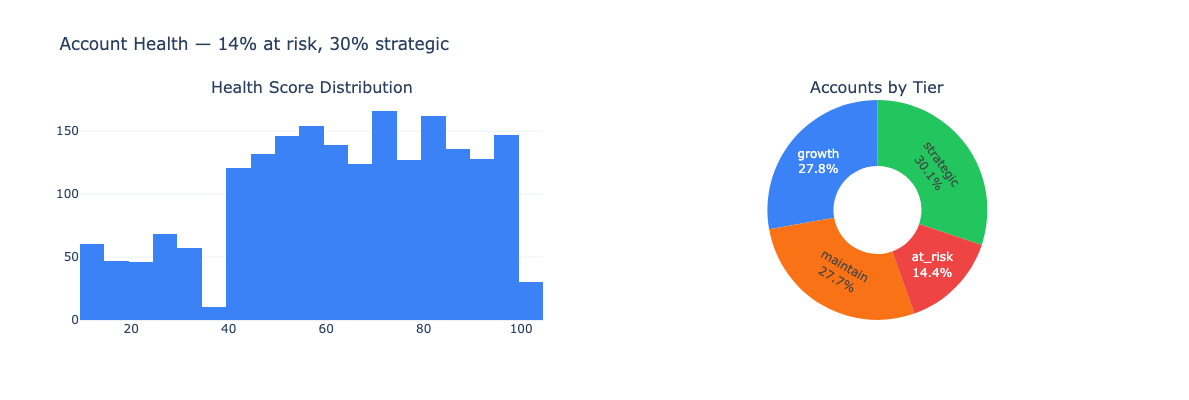


Account tier summary:
  strategic: 603 accounts (30%) | avg health: 90
  growth: 556 accounts (28%) | avg health: 70
  maintain: 553 accounts (28%) | avg health: 50
  at_risk: 288 accounts (14%) | avg health: 23


In [3]:
# ── Health score distribution with tier overlay ──
accounts = q("SELECT * FROM accounts")

fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Health Score Distribution", "Accounts by Tier"),
    specs=[[{"type": "xy"}, {"type": "domain"}]])

fig.add_trace(go.Histogram(x=accounts.health_score, nbinsx=30,
                            marker_color="#3b82f6"), row=1, col=1)

tier_counts = accounts.account_tier.value_counts()
colors = {"strategic":"#22c55e", "growth":"#3b82f6", "maintain":"#f97316", "at_risk":"#ef4444"}
fig.add_trace(go.Pie(labels=tier_counts.index, values=tier_counts.values,
                     marker_colors=[colors.get(t, "#94a3b8") for t in tier_counts.index],
                     hole=0.4, textinfo="label+percent"), row=1, col=2)

fig.update_layout(height=400, width=900, showlegend=False,
                  title_text="Account Health — 14% at risk, 30% strategic")
fig.show()

print("\nAccount tier summary:")
for tier in ["strategic", "growth", "maintain", "at_risk"]:
    d = accounts[accounts.account_tier == tier]
    print(f"  {tier}: {len(d):,} accounts ({len(d)/len(accounts)*100:.0f}%) | "
          f"avg health: {d.health_score.mean():.0f}")


## 3. Sales Activity — Volume and Mix

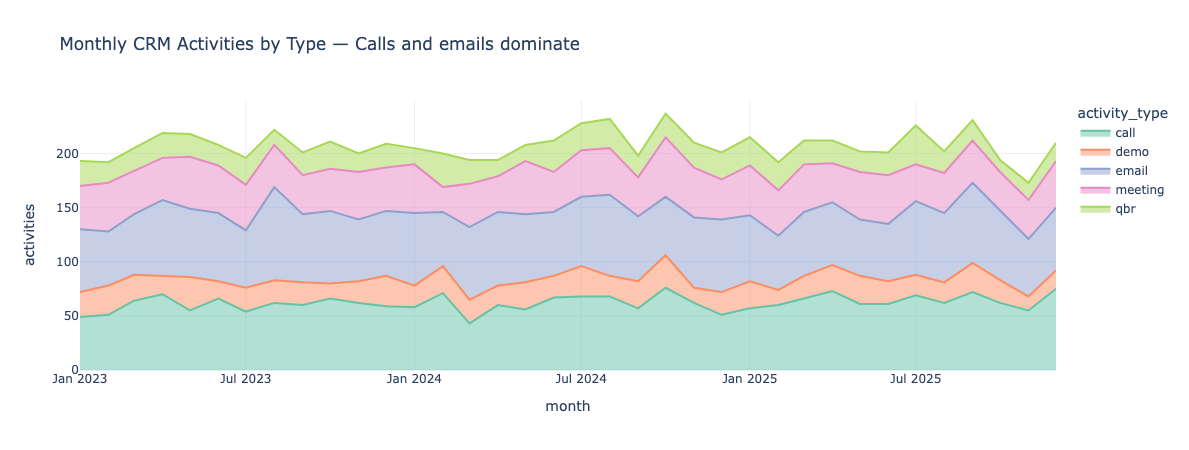

In [4]:
# ── Activity volume over time ──
act_monthly = q("""
    SELECT strftime('%Y-%m', activity_date) as month,
           activity_type, COUNT(*) as activities
    FROM v_activities_clean GROUP BY month, activity_type ORDER BY month
""")

fig = px.area(act_monthly, x="month", y="activities", color="activity_type",
              title="Monthly CRM Activities by Type — Calls and emails dominate",
              color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(height=450, width=1000)
fig.show()


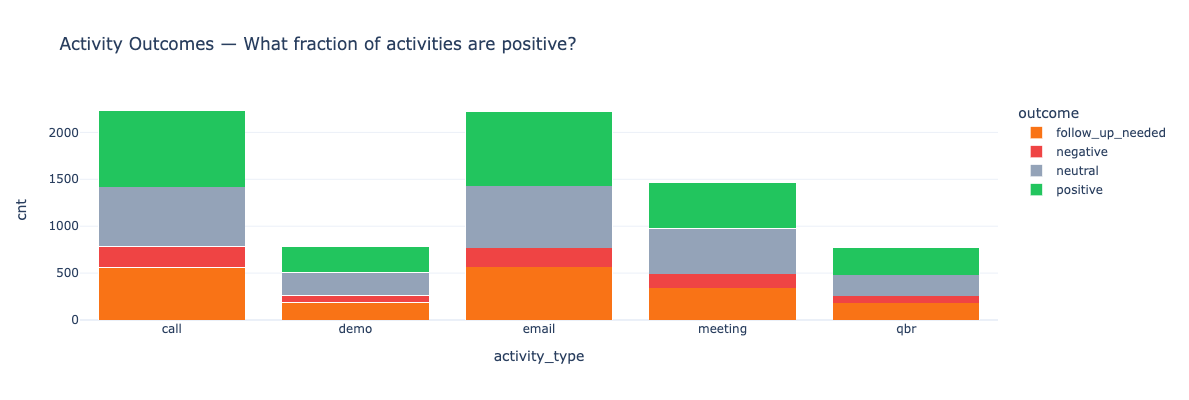

  call: 36% positive
  demo: 35% positive
  email: 36% positive
  meeting: 34% positive
  qbr: 38% positive


In [5]:
# ── Activity outcomes ──
outcomes = q("""
    SELECT activity_type, outcome, COUNT(*) as cnt
    FROM v_activities_clean GROUP BY activity_type, outcome
""")

fig = px.bar(outcomes, x="activity_type", y="cnt", color="outcome", barmode="stack",
             title="Activity Outcomes — What fraction of activities are positive?",
             color_discrete_map={"positive":"#22c55e", "neutral":"#94a3b8",
                                  "negative":"#ef4444", "follow_up_needed":"#f97316"})
fig.update_layout(height=400, width=800)
fig.show()

# Win rates by type
for atype in outcomes.activity_type.unique():
    d = outcomes[outcomes.activity_type == atype]
    total = d.cnt.sum()
    positive = d[d.outcome == "positive"].cnt.sum()
    print(f"  {atype}: {positive/total*100:.0f}% positive")


## 4. Sales Rep Performance

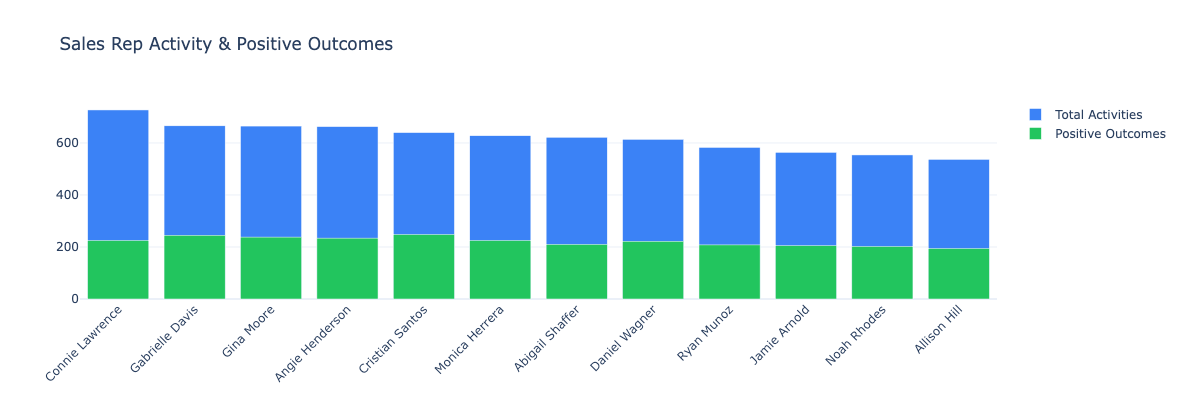


Rep leaderboard:
  Connie Lawrence: 727 activities | 181 accounts | 30.9% positive
  Gabrielle Davis: 666 activities | 170 accounts | 36.8% positive
  Gina Moore: 665 activities | 168 accounts | 35.8% positive
  Angie Henderson: 663 activities | 169 accounts | 35.3% positive
  Cristian Santos: 640 activities | 159 accounts | 38.8% positive


In [6]:
# ── Rep activity leaderboard ──
reps = q("""
    SELECT a2.owner as rep,
           COUNT(act.activity_id) as activities,
           COUNT(DISTINCT act.account_id) as accounts_touched,
           SUM(CASE WHEN act.outcome = 'positive' THEN 1 ELSE 0 END) as positive,
           ROUND(SUM(CASE WHEN act.outcome = 'positive' THEN 1.0 ELSE 0 END) / COUNT(*) * 100, 1) as win_rate
    FROM v_activities_clean act
    JOIN accounts a2 ON act.account_id = a2.account_id
    GROUP BY rep ORDER BY activities DESC
""")

fig = go.Figure()
fig.add_trace(go.Bar(x=reps.rep, y=reps.activities, name="Total Activities",
                     marker_color="#3b82f6"))
fig.add_trace(go.Bar(x=reps.rep, y=reps.positive, name="Positive Outcomes",
                     marker_color="#22c55e"))
fig.update_layout(barmode="overlay", title="Sales Rep Activity & Positive Outcomes",
                  height=400, width=950, xaxis_tickangle=-45)
fig.show()

print("\nRep leaderboard:")
for _, r in reps.head(5).iterrows():
    print(f"  {r.rep}: {r.activities:.0f} activities | {r.accounts_touched:.0f} accounts | {r.win_rate}% positive")


## 5. Opportunity Pipeline

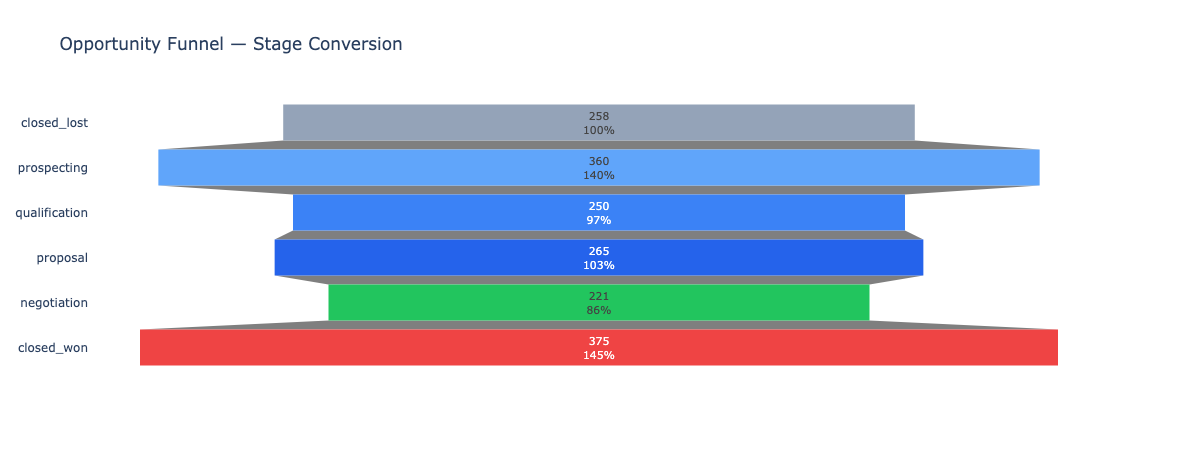


Pipeline summary:
  closed_lost: 258 deals | $32,567,985 total | $126,233 avg
  prospecting: 360 deals | $22,998,892 total | $63,886 avg
  qualification: 250 deals | $15,956,095 total | $63,824 avg
  proposal: 265 deals | $36,153,978 total | $136,430 avg
  negotiation: 221 deals | $26,848,435 total | $121,486 avg
  closed_won: 375 deals | $45,683,092 total | $121,822 avg


In [7]:
# ── Pipeline funnel ──
pipeline = q("""
    SELECT stage, COUNT(*) as deals, SUM(amount) as total_value,
           AVG(amount) as avg_deal, AVG(probability) as avg_prob
    FROM v_opportunities_clean GROUP BY stage ORDER BY avg_prob
""")

fig = go.Figure(go.Funnel(
    y=pipeline.stage, x=pipeline.deals,
    textinfo="value+percent initial",
    marker_color=["#94a3b8", "#60a5fa", "#3b82f6", "#2563eb", "#22c55e", "#ef4444"]
))
fig.update_layout(title="Opportunity Funnel — Stage Conversion", height=450, width=700)
fig.show()

print("\nPipeline summary:")
for _, r in pipeline.iterrows():
    print(f"  {r.stage}: {r.deals:.0f} deals | ${r.total_value:,.0f} total | ${r.avg_deal:,.0f} avg")


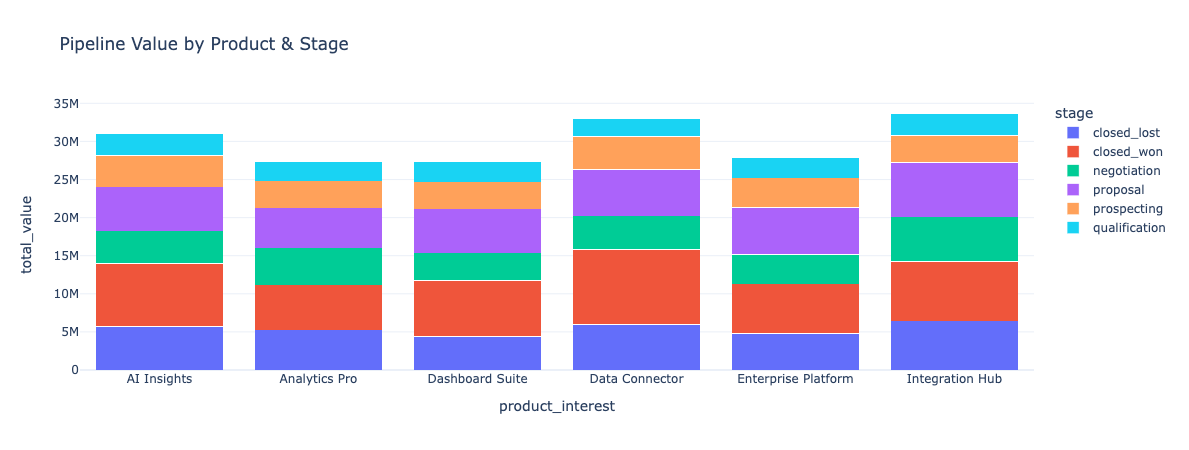

In [8]:
# ── Pipeline by product interest ──
by_product = q("""
    SELECT product_interest, stage,
           COUNT(*) as deals, SUM(amount) as total_value
    FROM v_opportunities_clean GROUP BY product_interest, stage
""")

fig = px.bar(by_product, x="product_interest", y="total_value", color="stage",
             barmode="stack", title="Pipeline Value by Product & Stage")
fig.update_layout(height=450, width=900)
fig.show()


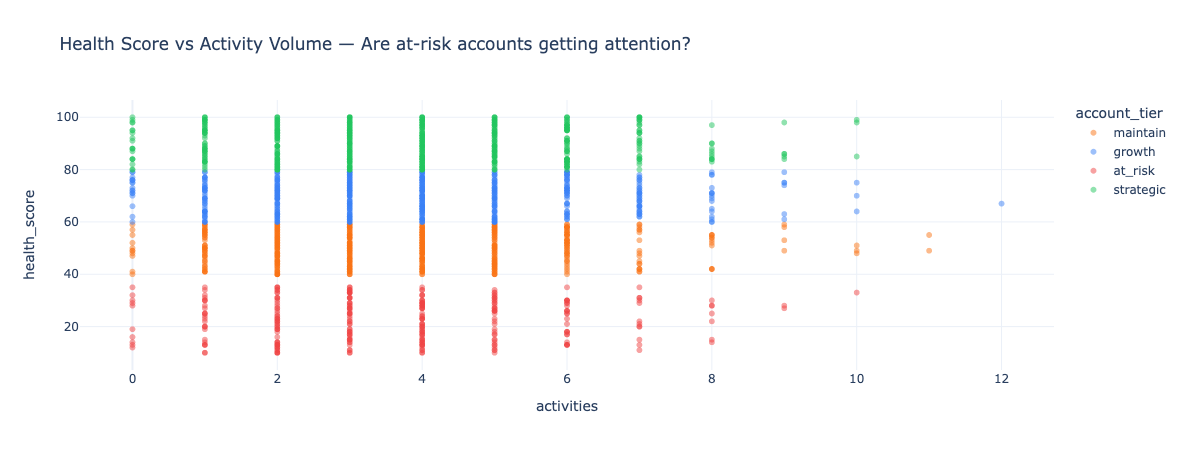


Avg activities by tier:
  strategic: 3.7 activities
  growth: 3.8 activities
  maintain: 3.7 activities
  at_risk: 3.6 activities


In [9]:
# ── Health score vs activity volume ──
health_activity = q("""
    SELECT a.account_id, a.health_score, a.account_tier,
           COUNT(act.activity_id) as activities,
           MAX(act.activity_date) as last_activity
    FROM accounts a
    LEFT JOIN v_activities_clean act ON a.account_id = act.account_id
    GROUP BY a.account_id, a.health_score, a.account_tier
""")

fig = px.scatter(health_activity, x="activities", y="health_score",
                 color="account_tier", title="Health Score vs Activity Volume — Are at-risk accounts getting attention?",
                 color_discrete_map={"strategic":"#22c55e", "growth":"#3b82f6",
                                      "maintain":"#f97316", "at_risk":"#ef4444"},
                 opacity=0.5, hover_data=["account_id"])
fig.update_layout(height=450, width=800)
fig.show()

print("\nAvg activities by tier:")
for tier in ["strategic", "growth", "maintain", "at_risk"]:
    avg = health_activity[health_activity.account_tier == tier].activities.mean()
    print(f"  {tier}: {avg:.1f} activities")


## 6. Summary & Key Findings

### Account Health
- **30% strategic, 28% growth, 28% maintain, 14% at-risk** — healthy distribution
- At-risk accounts (288) average health score of 23 — these need immediate attention
- Health score correlates with activity volume — the more engaged accounts are healthier

### Sales Activity
- **7,500 activities** over 3 years across 12 reps — ~625 per rep
- Calls and emails are highest volume; QBRs and demos are highest-intent
- ~35% of activities have positive outcomes — reasonable for B2B sales

### Pipeline
- **$206M total pipeline** across 2,000 opportunities
- Funnel conversion from prospecting → closed_won is healthy
- AI Insights and Analytics Pro drive the most pipeline value

### Data Quality
- 18% of activity notes are NULL (sales reps skipping notes — realistic)
- 38 notes flagged as truncated
- 37 activities excluded for future date typos (2032, 2042, 2052)
- 271 opportunities excluded (close_date beyond 2025-12-31)

### Recommendations
- At-risk accounts need more activity, not less — increase touch frequency
- Track demo → closed_won conversion rate as a rep effectiveness metric
- QBR frequency should increase for growth-tier accounts approaching renewal

In [ ]:
conn.close()
print('Notebook complete.')